In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("Student_Performance.csv")

In [ ]:
df.head()

,Unnamed: 0,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1.0,91
1,4,82,No,4,2.0,65
2,8,51,Yes,7,2.0,45
3,5,52,Yes,5,2.0,36
4,7,75,No,8,5.0,66


In [ ]:
df.shape

(10000, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Unnamed: 0                        10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        8428 non-null   object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  7144 non-null   float64
 5   Performance Index                 10000 non-null  int64  
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [ ]:
df.describe()

,Unnamed: 0,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,7144.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.572788,55.224800
std,2.589309,17.343152,1.695863,2.868633,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [ ]:
df.columns

Index(['Unnamed: 0', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [ ]:
df.drop(['Unnamed: 0'],axis=1,inplace=True)

In [ ]:
df.duplicated().sum()

307

In [ ]:
df.isnull().sum().sort_values(ascending=False)/df.shape[0]*100

Sample Question Papers Practiced    28.56
Extracurricular Activities          15.72
Previous Scores                      0.00
Sleep Hours                          0.00
Performance Index                    0.00
dtype: float64

In [ ]:
df.corr(numeric_only=True)

,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
Previous Scores,1.000000,0.005944,0.002829,0.915189
Sleep Hours,0.005944,1.000000,0.009612,0.048106
Sample Question Papers Practiced,0.002829,0.009612,1.000000,0.036898
Performance Index,0.915189,0.048106,0.036898,1.000000


In [ ]:
df.drop(['Sample Question Papers Practiced'],axis=1,inplace=True)

In [ ]:
df['Extracurricular Activities'].unique()

array(['Yes', 'No', nan], dtype=object)

In [ ]:
df_new = df.dropna(axis=0)

In [ ]:
from sklearn.impute import SimpleImputer

In [ ]:
imputer = SimpleImputer(strategy='most_frequent')

In [ ]:
df[['Extracurricular Activities']] = imputer.fit_transform(df[['Extracurricular Activities']])

In [ ]:
df.duplicated().sum()

2163

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.head()

,Previous Scores,Extracurricular Activities,Sleep Hours,Performance Index
0,99,Yes,9,91
1,82,No,4,65
2,51,Yes,7,45
3,52,Yes,5,36
4,75,No,8,66


<Axes: xlabel='Sleep Hours', ylabel='Performance Index'>

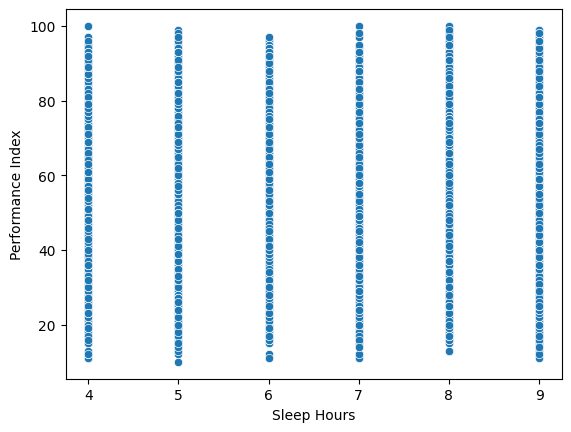

In [ ]:
sns.scatterplot(data=df,x='Sleep Hours',y='Performance Index')

<Axes: xlabel='Previous Scores', ylabel='Performance Index'>

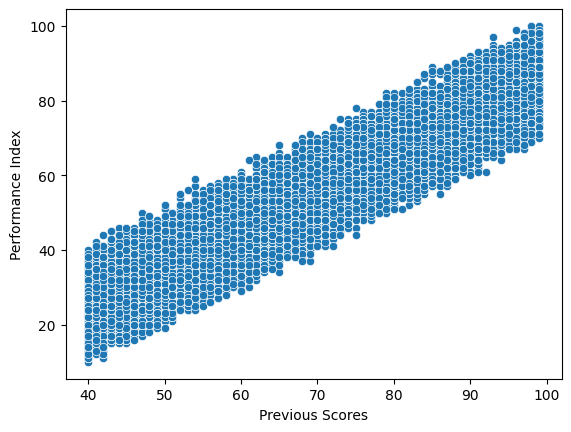

In [ ]:
sns.scatterplot(data=df,x='Previous Scores',y='Performance Index')

<Axes: xlabel='Previous Scores', ylabel='Performance Index'>

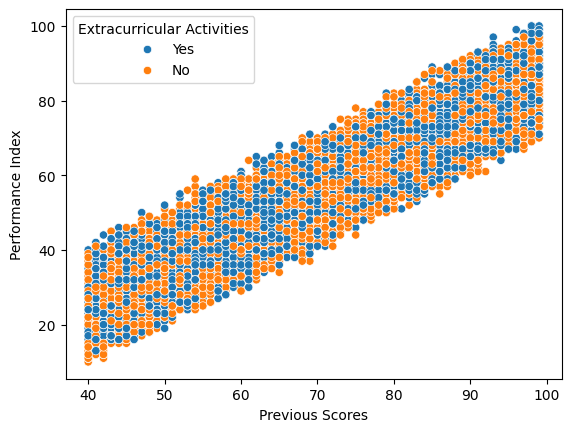

In [ ]:
sns.scatterplot(data=df,x='Previous Scores',y='Performance Index',hue='Extracurricular Activities')

<Axes: xlabel='Previous Scores', ylabel='Count'>

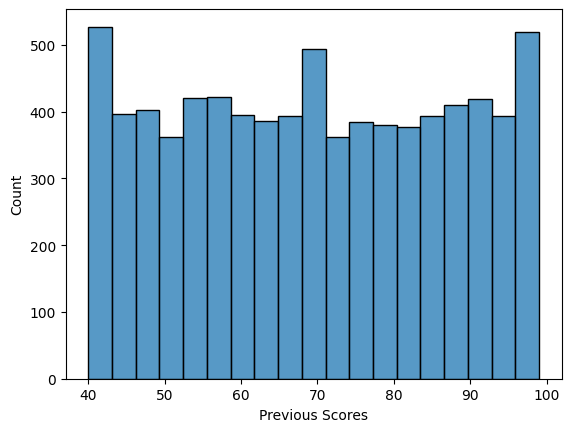

In [ ]:
sns.histplot(df['Previous Scores'])

<Axes: xlabel='Performance Index', ylabel='Count'>

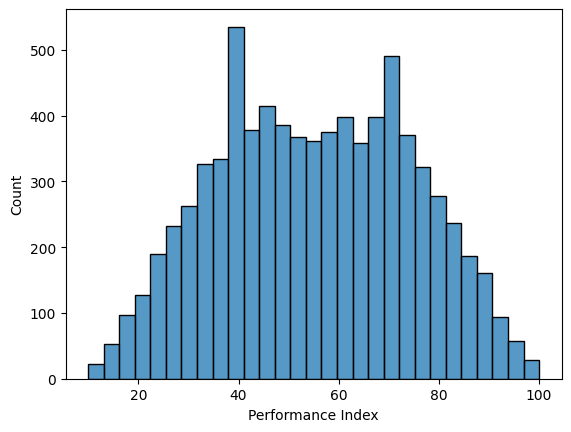

In [ ]:
sns.histplot(df['Performance Index'])

<Axes: xlabel='count', ylabel='Extracurricular Activities'>

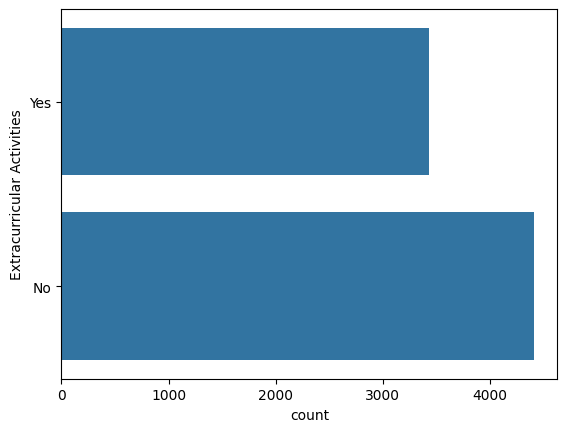

In [ ]:
sns.countplot(df['Extracurricular Activities'])

<Axes: >

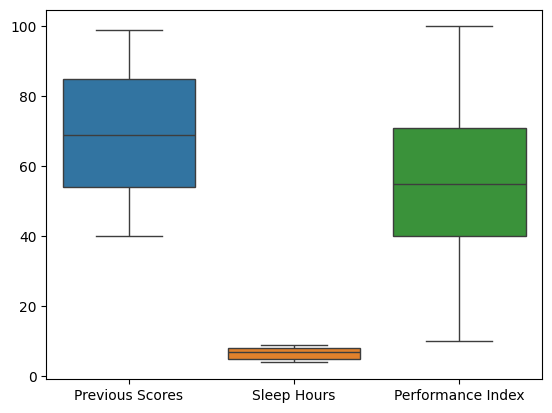

In [ ]:
sns.boxplot(df)

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
onehotencoder = OneHotEncoder()

In [ ]:
W = onehotencoder.fit_transform(df[['Extracurricular Activities']]).toarray()

In [ ]:
onehotencoder.categories_[0]

array(['No', 'Yes'], dtype=object)

In [ ]:
for ind , col in enumerate(onehotencoder.categories_[0]):
    df[col]=W[:,ind]
    #df['No']=W[:,0]
    #df['Yes']=W[:,1]
    print(ind,col)

0 No
1 Yes


In [ ]:
df.head()

,Previous Scores,Extracurricular Activities,Sleep Hours,Performance Index,No,Yes
0,99,Yes,9,91,0.0,1.0
1,82,No,4,65,1.0,0.0
2,51,Yes,7,45,0.0,1.0
3,52,Yes,5,36,0.0,1.0
4,75,No,8,66,1.0,0.0


In [ ]:
df.drop('Extracurricular Activities',axis=1,inplace=True)

In [ ]:
df.head()

,Previous Scores,Sleep Hours,Performance Index,No,Yes
0,99,9,91,0.0,1.0
1,82,4,65,1.0,0.0
2,51,7,45,0.0,1.0
3,52,5,36,0.0,1.0
4,75,8,66,1.0,0.0


In [ ]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler

In [ ]:
scaler_stand=StandardScaler()
sclar_minmax=MinMaxScaler()

In [ ]:
#df['Performance Index'] = scaler_stand.fit_transform(df[['Performance Index']])

In [ ]:
df['Previous Scores'] = sclar_minmax.fit_transform(df[['Previous Scores']])

In [ ]:
df['Sleep Hours'] = sclar_minmax.fit_transform(df[['Sleep Hours']])

In [ ]:
y=df['Performance Index']

In [ ]:
X=df.drop('Performance Index',axis=1)

In [ ]:
y

0       91
1       65
2       45
3       36
4       66
        ..
9991    83
9993    55
9995    23
9996    58
9997    74
Name: Performance Index, Length: 7837, dtype: int64

In [ ]:
X

,Previous Scores,Sleep Hours,No,Yes
0,1.000000,1.0,0.0,1.0
1,0.711864,0.0,1.0,0.0
2,0.186441,0.6,0.0,1.0
3,0.203390,0.2,0.0,1.0
4,0.593220,0.8,1.0,0.0
...,...,...,...,...
9991,0.966102,0.6,0.0,1.0
9993,0.305085,0.6,0.0,1.0
9995,0.152542,0.0,0.0,1.0
9996,0.406780,0.8,0.0,1.0


In [ ]:
from sklearn.model_selection import  train_test_split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [ ]:
from sklearn.linear_model import LinearRegression,Lasso,Ridge

In [ ]:
model = Ridge()#Lasso()#LinearRegression()

In [ ]:
model.fit(X_train,y_train)

Ridge()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
y_pred[:5],y_test[:5]

(array([59.86799831, 29.64924712, 30.35099916, 48.02528899, 39.87686371]),
 6227    50
 2517    40
 8503    37
 2883    41
 4803    51
 Name: Performance Index, dtype: int64)

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [ ]:
print('MAE: ',mean_absolute_error(y_test,y_pred))

MAE:  6.831933784530013


In [ ]:
print('MSE: ',mean_squared_error(y_test,y_pred))

MSE:  62.96517586227285


In [ ]:
print('MSE: ',np.sqrt(mean_squared_error(y_test,y_pred)))

MSE:  7.935059915480969


In [ ]:
print('R2: ',r2_score(y_test,y_pred))

R2:  0.832697994970403
